In [1]:
import paicos as pa
import numpy as np
import turbocluster as tc

pa.settings.strict_units = False

# A snapshot object
snap = pa.Snapshot(pa.data_dir, 247)
center = snap.Cat.Group['GroupPos'][0]
widths = np.array([2000., 2000., 2000.], dtype=float)
arepo_length = snap['0_Diameters'].uq

threadsperblock = 64
npix = 128

In [2]:
depo = tc.DepositCartesianGrid(snap, center, widths, npix=npix, threadsperblock=threadsperblock, 
                               regionType='cartesian', kernel_type="PCS")

No `pos' argument given. Defaults to gas particles
No `hsml' argument given. Defaults to gas particles


In [3]:
density_cartesian = depo.deposit_variable('0_Density', weight='0_Volume')

In [4]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize

widths_slicer = widths.copy()
widths_slicer[2] = 0.
slicer = pa.Slicer(snap, center, widths_slicer, 'z', npix=1024)
extent = slicer.centered_extent.to('Mpc')

Text(0.5, 0.95, 'Density field (voronoi and cartesian)')

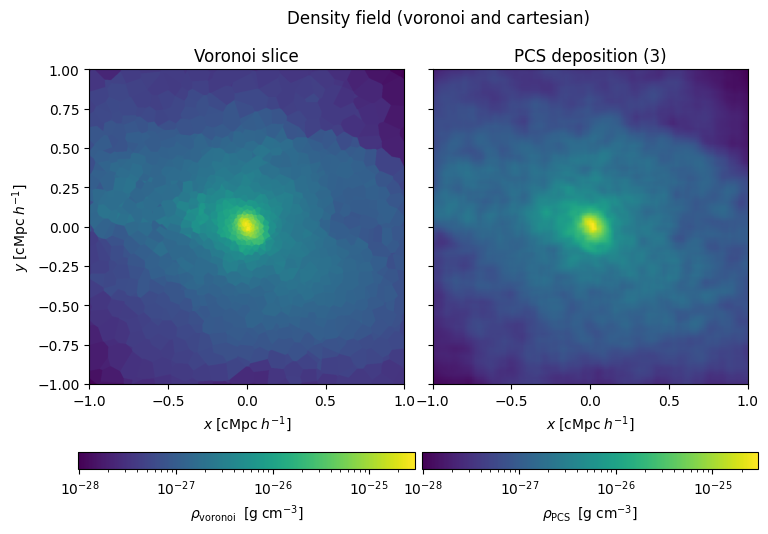

In [5]:

""" 
I am not sure why here I need to transpose to make sure
the alignment is the same as the slice
""" 
dens_voro = slicer.slice_variable('0_Density')
dens_cart_PCS = (density_cartesian[:,:,int(depo.npoints[2]//2)-1].T).to_physical.cgs

dens_voro = dens_voro.to_physical.cgs

vmin = np.min(dens_voro.value)
vmax = np.max(dens_voro.value)
norm = LogNorm(vmin=vmin,vmax=vmax)


fig, axes = plt.subplots(1,2, figsize=(8,6),sharex=True, sharey=True)

im1 = axes[0].imshow(
    dens_voro.value, origin='lower', norm=norm,extent=extent.value)

im2 = axes[1].imshow(
    dens_cart_PCS.value, origin='lower', norm=norm,extent=extent.value)


axes[0].set_title('Voronoi slice')
axes[1].set_title('PCS deposition (3)')


for i in range(2):
    axes[i].set_xlabel(extent.label('x'))

axes[0].set_ylabel(extent.label('y'))

cbar = fig.colorbar(im1, orientation='horizontal')
cbar.set_label(dens_voro.label('\\rho_{\\mathrm{voronoi}}'))

cbar = fig.colorbar(im2, orientation='horizontal')
cbar.set_label(dens_cart_PCS.label('\\rho_{\\mathrm{PCS}}'))


fig.subplots_adjust(top=0.85,
bottom=0.1,
left=0.05,
right=0.90,
hspace=0.0,
wspace=0.02)

fig.suptitle('Density field (voronoi and cartesian)',y=0.95)

In [6]:
from turbocluster.utils.power_spectra_utils import power_spectrum1d

In [7]:
powerspectr, k1d, _ = power_spectrum1d(depo, density_cartesian)

energy (real space) = 2.9551e-01
energy (fourier space) = 2.9551e-01


In [8]:
depo_CIC = tc.DepositCartesianGrid(snap, center, widths, npix=npix, threadsperblock=threadsperblock, 
                               regionType='cartesian', kernel_type="CIC")
density_cartesian_CIC = depo_CIC.deposit_variable('0_Density', weight='0_Volume')
powerspectr_CIC, k1d, _ = power_spectrum1d(depo_CIC, density_cartesian_CIC)

No `pos' argument given. Defaults to gas particles
No `hsml' argument given. Defaults to gas particles
energy (real space) = 3.1206e-01
energy (fourier space) = 3.1206e-01


In [9]:
depo_HR = tc.DepositCartesianGrid(snap, center, widths, npix=2*npix, threadsperblock=threadsperblock, 
                               regionType='cartesian', kernel_type="PCS")
density_cartesian_HR = depo_HR.deposit_variable('0_Density', weight='0_Volume')
powerspectr_HR, k1d_HR, _ = power_spectrum1d(depo_HR,density_cartesian_HR)

No `pos' argument given. Defaults to gas particles
No `hsml' argument given. Defaults to gas particles
energy (real space) = 3.0433e-01
energy (fourier space) = 3.0433e-01


In [10]:
import scipy

In [11]:
depo_wind = tc.DepositCartesianGrid(snap, center, widths, npix=npix, threadsperblock=threadsperblock, 
                               regionType='cartesian', kernel_type="PCS")
density_cartesian_wind = depo_wind.deposit_variable('0_Density', weight='0_Volume')
powerspectr_windowed, k1d_windowed, (KX, KY, KZ, hat_depo_variable) = power_spectrum1d(depo_wind, 
                                                                                          density_cartesian, npads=1,
                                                              window=scipy.signal.windows.hann)

No `pos' argument given. Defaults to gas particles
No `hsml' argument given. Defaults to gas particles
energy (real space) = 2.9551e-01
energy (fourier space) = 8.5596e-01


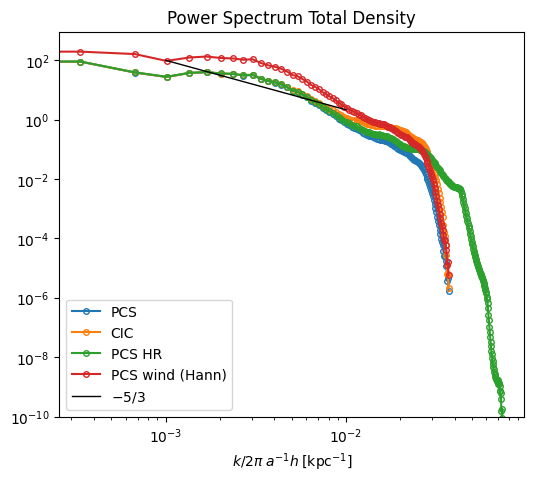

In [12]:
fig, ax = plt.subplots(figsize=(6,5))

t = np.logspace(np.log10(1e-3),np.log10(1e-2), 100)

ax.plot(k1d.to_physical.to('1/kpc')/(2.0*np.pi), powerspectr, ls='-', marker='o', markerfacecolor='none', 
        markersize=4, label='PCS')

ax.plot(k1d.to_physical.to('1/kpc')/(2.0*np.pi), powerspectr_CIC, ls='-', marker='o', markerfacecolor='none', 
        markersize=4, label='CIC')

ax.plot(k1d_HR.to_physical.to('1/kpc')/(2.0*np.pi), powerspectr_HR, ls='-', marker='o', 
        markerfacecolor='none', markersize=4, label='PCS HR')

ax.plot(k1d_windowed.to_physical.to('1/kpc')/(2.0*np.pi), powerspectr_windowed, ls='-', marker='o', 
        markerfacecolor='none', markersize=4, label='PCS wind (Hann)')


ax.plot(t, 1e-3*t**(-5./3.), ls='-', color='k',label=r'$-5/3$',lw=1.)


ax.set_xlabel(k1d.astro.label('k / 2 \\pi'))
ax.set_xscale('log')
ax.set_yscale('log')

ax.legend()

ax.set_title(r'Power Spectrum of the density')


ax.set_ylim(ymin=1e-10)
# ax.set_ylim(ymin=1e-10)
# ax[1].set_xlim(xmax=30)

plt.show()
